# Ice Rheology Part 2: Elasticity and Viscoelasticity — Figures

**Ge 193 — Glacier Dynamics, Spring 2026**

This notebook generates figures for the *Ice Rheology Part 2* lecture on elasticity and viscoelasticity of ice, including Maxwell viscoelastic responses, tidal flexure profiles, and the Deborah number regime diagram.

In [1]:
# ---- Setup: imports and physical constants ----
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('figures', exist_ok=True)

# Elastic moduli of polycrystalline ice (Gammon et al. 1983)
E = 9.33e9       # Pa, Young's modulus
mu = 3.52e9      # Pa, shear modulus
K = 8.90e9       # Pa, bulk modulus
nu = 0.325       # Poisson's ratio
lam = 6.55e9     # Pa, first Lame parameter

# Densities
rho_i = 917.0    # kg m^{-3}, ice
rho_w = 1025.0   # kg m^{-3}, seawater
g = 9.8          # m s^{-2}

# Glen's law parameters
R_gas = 8.314    # J mol^{-1} K^{-1}
n_glen = 3

def A_glen(T):
    """Rate factor A(T) using Arrhenius relation (Pa^{-3} s^{-1})."""
    A0_cold, Q_cold = 3.5e-25 / np.exp(-60e3 / (R_gas * 263)), 60e3
    A0_warm, Q_warm = 3.5e-25 / np.exp(-139e3 / (R_gas * 263)) * np.exp(139e3 / (R_gas * 263)) / np.exp(60e3 / (R_gas * 263)), 139e3
    # Simpler: use Cuffey & Paterson values directly
    # At 263 K: A = 3.5e-25; use Q=60 below 263, Q=139 above
    Q = np.where(T < 263, 60e3, 139e3)
    A_ref = 3.5e-25  # at T_ref = 263 K
    T_ref = 263.0
    Q_ref = 60e3
    return A_ref * np.exp(-Q / R_gas * (1/T - 1/T_ref) + Q_ref / R_gas * (1/T_ref - 1/T_ref))

# Simpler: just compute A for specific temperatures
def A_at_T(T):
    """Rate factor for specific T values."""
    A_ref = 3.5e-25  # Pa^{-3} s^{-1} at 263 K
    T_ref = 263.0
    Q = np.where(np.asarray(T) < 263, 60e3, 139e3)
    return A_ref * np.exp(-Q / R_gas * (1.0 / np.asarray(T) - 1.0 / T_ref))

def maxwell_time(T, tau_e):
    """Maxwell relaxation time (s). T in K, tau_e in Pa."""
    A = A_at_T(T)
    return 1.0 / (2 * mu * A * tau_e**2)

def flexural_wavelength(h):
    """Flexural wavelength (m) for ice shelf of thickness h (m)."""
    D = E * h**3 / (12 * (1 - nu**2))
    return (4 * D / (rho_w * g))**0.25

print('Setup complete.')

Setup complete.


---
## Figure 1: Maxwell Viscoelastic Response to Step Loading

Three panels showing the response of a linear Maxwell material to (a) step stress (creep test), (b) step strain (relaxation test), and (c) oscillatory stress (harmonic forcing). These illustrate eqs. (19)–(21) in the lecture notes.

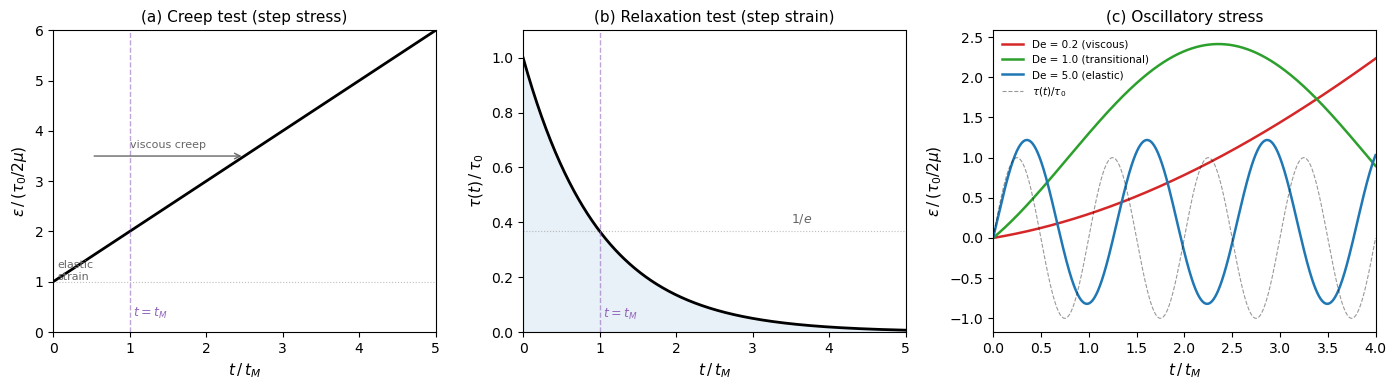

Figure 1 saved.


In [2]:
# ---- Fig 1: Maxwell viscoelastic responses (3 panels) ----
t_M = 1.0  # normalized Maxwell time
tau_0 = 1.0
eps_0 = 1.0
eta = mu * t_M  # effective viscosity (normalized)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# --- (a) Creep test: step stress ---
ax = axes[0]
t_a = np.linspace(0, 5 * t_M, 500)
eps_creep = tau_0 / (2 * mu) * (1 + t_a / t_M)

# Stress input (top sub-axis via twinx)
ax.plot(t_a / t_M, eps_creep * 2 * mu / tau_0, 'k-', lw=2)
ax.axhline(1.0, color='gray', ls=':', lw=0.8, alpha=0.5)
ax.axvline(1.0, color='#9467bd', ls='--', lw=1, alpha=0.6)
ax.text(1.05, 0.3, '$t = t_M$', fontsize=9, color='#9467bd')

# Annotations
ax.annotate('elastic\nstrain', xy=(0.05, 1.0), fontsize=8, color='0.4',
            ha='left', va='bottom')
ax.annotate('', xy=(2.5, 3.5), xytext=(0.5, 3.5),
            arrowprops=dict(arrowstyle='->', color='0.4', lw=1))
ax.text(1.5, 3.65, 'viscous creep', fontsize=8, color='0.4', ha='center')

ax.set_xlabel('$t \\,/\\, t_M$', fontsize=11)
ax.set_ylabel('$\\varepsilon \\,/\\, (\\tau_0 / 2\\mu)$', fontsize=11)
ax.set_title('(a) Creep test (step stress)', fontsize=11)
ax.set_xlim(0, 5)
ax.set_ylim(0, 6)

# --- (b) Relaxation test: step strain ---
ax = axes[1]
t_b = np.linspace(0, 5 * t_M, 500)
tau_relax = np.exp(-t_b / t_M)

ax.plot(t_b / t_M, tau_relax, 'k-', lw=2)
ax.axhline(1/np.e, color='gray', ls=':', lw=0.8, alpha=0.5)
ax.axvline(1.0, color='#9467bd', ls='--', lw=1, alpha=0.6)
ax.text(1.05, 0.05, '$t = t_M$', fontsize=9, color='#9467bd')
ax.text(3.5, 1/np.e + 0.03, '$1/e$', fontsize=9, color='0.4')

ax.fill_between(t_b / t_M, tau_relax, alpha=0.1, color='#1f77b4')

ax.set_xlabel('$t \\,/\\, t_M$', fontsize=11)
ax.set_ylabel('$\\tau(t) \\,/\\, \\tau_0$', fontsize=11)
ax.set_title('(b) Relaxation test (step strain)', fontsize=11)
ax.set_xlim(0, 5)
ax.set_ylim(0, 1.1)

# --- (c) Harmonic forcing ---
ax = axes[2]
omega = 2 * np.pi  # angular frequency (period = 1 t_M)
t_c = np.linspace(0, 4, 1000)  # in units of t_M

# Three Deborah numbers
De_vals = [0.2, 1.0, 5.0]
colors_c = ['#d62728', '#2ca02c', '#1f77b4']
labels_c = ['De = 0.2 (viscous)', 'De = 1.0 (transitional)', 'De = 5.0 (elastic)']

for De, col, lab in zip(De_vals, colors_c, labels_c):
    omega_val = De / t_M  # omega = De / t_M
    t_phys = t_c * t_M
    # Strain response: eps = tau_0/(2mu) sin(omega t) + tau_0/(2 eta omega)(1 - cos(omega t))
    eps_harm = (tau_0 / (2 * mu)) * np.sin(omega_val * t_phys) \
             + (tau_0 / (2 * eta * omega_val)) * (1 - np.cos(omega_val * t_phys))
    # Normalize by tau_0/(2mu)
    eps_norm = eps_harm / (tau_0 / (2 * mu))
    ax.plot(t_c, eps_norm, '-', color=col, lw=1.8, label=lab)

# Stress input for reference (dashed)
ax.plot(t_c, np.sin(2 * np.pi * t_c), 'k--', lw=0.8, alpha=0.4, label='$\\tau(t)/\\tau_0$')

ax.set_xlabel('$t \\,/\\, t_M$', fontsize=11)
ax.set_ylabel('$\\varepsilon \\,/\\, (\\tau_0 / 2\\mu)$', fontsize=11)
ax.set_title('(c) Oscillatory stress', fontsize=11)
ax.set_xlim(0, 4)
ax.legend(fontsize=7.5, frameon=False, loc='upper left')

fig.tight_layout()
fig.savefig('figures/fig01_maxwell_responses.pdf', bbox_inches='tight')
fig.savefig('figures/fig01_maxwell_responses.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

---
## Figure 2: Maxwell Time as a Function of Stress and Temperature

Contour plot of $t_M(\tau_e, T)$ showing the enormous range of Maxwell times across glaciological conditions. Overlaid markers show the settings from Table 2 in the lecture notes.

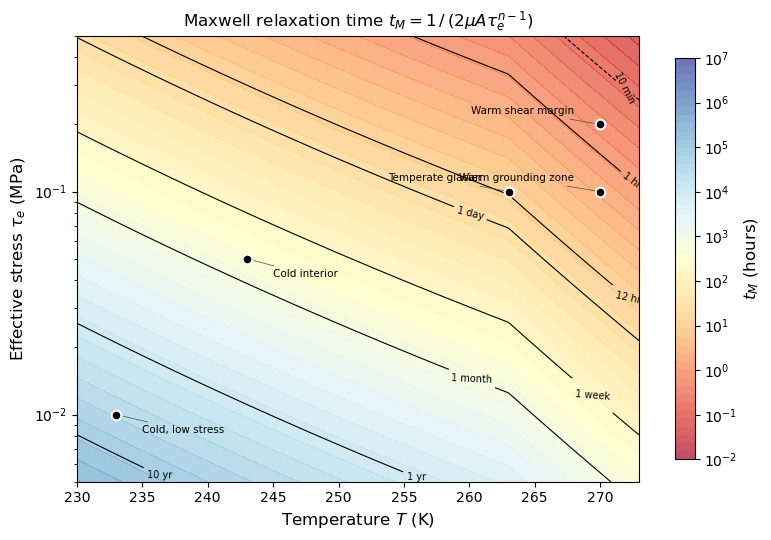

Figure 2 saved.


In [3]:
# ---- Fig 2: Maxwell time contour plot ----
from matplotlib.ticker import FuncFormatter

T_arr = np.linspace(230, 273, 300)
tau_arr = np.logspace(np.log10(0.005), np.log10(0.5), 300)  # MPa
T_grid, tau_grid = np.meshgrid(T_arr, tau_arr)

# Compute Maxwell time in hours
t_M_grid = maxwell_time(T_grid, tau_grid * 1e6) / 3600  # hours

fig, ax = plt.subplots(figsize=(8, 5.5))

# Contour levels in hours: 1 min, 10 min, 1 hr, 12 hr, 1 day, 1 week, 1 month, 1 yr, 10 yr, 100 yr
levels_hr = [1/60, 10/60, 1, 12, 24, 24*7, 24*30, 24*365, 24*365*10, 24*365*100, 24*365*1000]
level_labels = ['1 min', '10 min', '1 hr', '12 hr', '1 day', '1 week', '1 month',
                '1 yr', '10 yr', '100 yr', '1000 yr']

cs = ax.contour(T_arr, tau_arr, np.log10(t_M_grid), 
                levels=np.log10(levels_hr), colors='k', linewidths=0.8)

# Manual labels for contours
ax.clabel(cs, cs.levels, inline=True, fontsize=7,
          fmt={lev: lab for lev, lab in zip(np.log10(levels_hr), level_labels)})

# Fill with color
cf = ax.contourf(T_arr, tau_arr, np.log10(t_M_grid),
                 levels=np.linspace(-2, 7, 50), cmap='RdYlBu', alpha=0.7)

# Colorbar with 10^x formatting
cbar = fig.colorbar(cf, ax=ax, shrink=0.9)
cbar.set_label('$t_M$ (hours)', fontsize=12)

# Set colorbar ticks at integer powers and format as 10^x
cbar_ticks = np.arange(-2, 8)  # 10^-2 to 10^7 hours
cbar.set_ticks(cbar_ticks)
cbar.set_ticklabels([f'$10^{{{int(t)}}}$' for t in cbar_ticks])

# Mark Table 2 settings
table_settings = [
    (270, 0.2, 'Warm shear margin'),
    (270, 0.1, 'Warm grounding zone'),
    (263, 0.1, 'Temperate glacier'),
    (243, 0.05, 'Cold interior'),
    (233, 0.01, 'Cold, low stress'),
]
for T_val, tau_val, label in table_settings:
    ax.plot(T_val, tau_val, 'ko', ms=7, markeredgecolor='white', markeredgewidth=1.5, zorder=5)
    # Offset labels to avoid overlap
    dx = -2 if T_val > 250 else 2
    dy_factor = 1.15 if tau_val > 0.05 else 0.85
    ax.annotate(label, xy=(T_val, tau_val), xytext=(T_val + dx, tau_val * dy_factor),
                fontsize=7.5, ha='right' if T_val > 250 else 'left', va='center',
                arrowprops=dict(arrowstyle='-', color='0.3', lw=0.5))

ax.set_yscale('log')
ax.set_xlabel('Temperature $T$ (K)', fontsize=12)
ax.set_ylabel('Effective stress $\\tau_e$ (MPa)', fontsize=12)
ax.set_title('Maxwell relaxation time $t_M = 1 \\,/\\, (2\\mu A \\tau_e^{n-1})$', fontsize=12)
ax.set_xlim(230, 273)
ax.set_ylim(0.005, 0.5)

fig.tight_layout()
fig.savefig('figures/fig02_maxwell_time_contours.pdf', bbox_inches='tight')
fig.savefig('figures/fig02_maxwell_time_contours.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

---
## Figure 3: Tidal Flexure Profile at a Grounding Zone

Plot the elastic tidal flexure solution $w(x) = w_0[1 - e^{-x/\ell_f}(\cos(x/\ell_f) + \sin(x/\ell_f))]$ for three ice thicknesses, showing how the flexural wavelength controls the adjustment from grounded to floating ice.

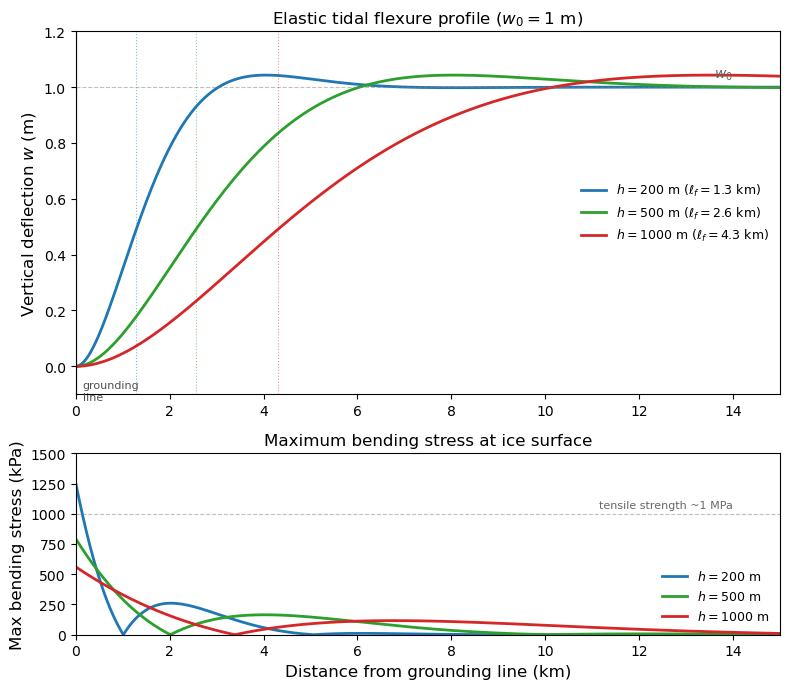

Figure 3 saved.


In [4]:
# ---- Fig 3: Tidal flexure profiles ----
x = np.linspace(0, 15000, 1000)  # m

thicknesses = [200, 500, 1000]  # m
colors_flex = ['#1f77b4', '#2ca02c', '#d62728']

w_0 = 1.0  # m, tidal amplitude

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), gridspec_kw={'height_ratios': [2, 1]})

for h, col in zip(thicknesses, colors_flex):
    lf = flexural_wavelength(h)
    xi = x / lf
    w = w_0 * (1 - np.exp(-xi) * (np.cos(xi) + np.sin(xi)))
    
    ax1.plot(x / 1e3, w, '-', color=col, lw=2,
             label=f'$h = {h}$ m ($\\ell_f = {lf/1e3:.1f}$ km)')
    
    # Mark ell_f on the plot
    ax1.axvline(lf / 1e3, color=col, ls=':', lw=0.8, alpha=0.5)

ax1.axhline(w_0, color='gray', ls='--', lw=0.8, alpha=0.5)
ax1.text(14, w_0 + 0.02, '$w_0$', fontsize=10, color='0.4', va='bottom', ha='right')
ax1.axvline(0, color='k', ls='-', lw=1.5)
ax1.text(0.15, -0.05, 'grounding\nline', fontsize=8, color='0.3', va='top')

ax1.set_ylabel('Vertical deflection $w$ (m)', fontsize=12)
ax1.set_title('Elastic tidal flexure profile ($w_0 = 1$ m)', fontsize=12)
ax1.legend(fontsize=9, frameon=False, loc='center right')
ax1.set_xlim(0, 15)
ax1.set_ylim(-0.1, 1.2)

# Lower panel: bending stress
for h, col in zip(thicknesses, colors_flex):
    lf = flexural_wavelength(h)
    xi = x / lf
    # d2w/dx2 = (2 w_0 / lf^2) * exp(-xi) * sin(xi)
    # Wait, let me derive: w'(xi) = 2 w_0 exp(-xi) sin(xi) (from the notes)
    # w''(xi) = 2 w_0 [exp(-xi)(cos(xi) - sin(xi))]... 
    # Actually d2w/dx2 = (1/lf^2) d2w/dxi2
    # w(xi) = w_0 [1 - exp(-xi)(cos xi + sin xi)]
    # dw/dxi = w_0 * 2 exp(-xi) sin(xi)
    # d2w/dxi2 = w_0 * 2 [exp(-xi)(cos xi - sin xi)]
    d2w_dx2 = w_0 * 2 * np.exp(-xi) * (np.cos(xi) - np.sin(xi)) / lf**2
    sigma_bend = E * h / (2 * (1 - nu**2)) * np.abs(d2w_dx2) / 1e3  # kPa
    
    ax2.plot(x / 1e3, sigma_bend, '-', color=col, lw=2, label=f'$h = {h}$ m')

ax2.axhline(1000, color='gray', ls='--', lw=0.8, alpha=0.5)
ax2.text(14, 1050, 'tensile strength ~1 MPa', fontsize=8, color='0.4', ha='right')

ax2.set_xlabel('Distance from grounding line (km)', fontsize=12)
ax2.set_ylabel('Max bending stress (kPa)', fontsize=12)
ax2.set_title('Maximum bending stress at ice surface', fontsize=12)
ax2.set_xlim(0, 15)
ax2.set_ylim(0, 1500)
ax2.legend(fontsize=9, frameon=False)

fig.tight_layout()
fig.savefig('figures/fig03_tidal_flexure.pdf', bbox_inches='tight')
fig.savefig('figures/fig03_tidal_flexure.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

---
## Figure 4: Deborah Number Regime Diagram

Plot the Deborah number $\text{De} = t_M / t_p$ as a function of process timescale $t_p$ for several glaciological stress/temperature conditions, showing which processes are elastic, viscous, or viscoelastic.

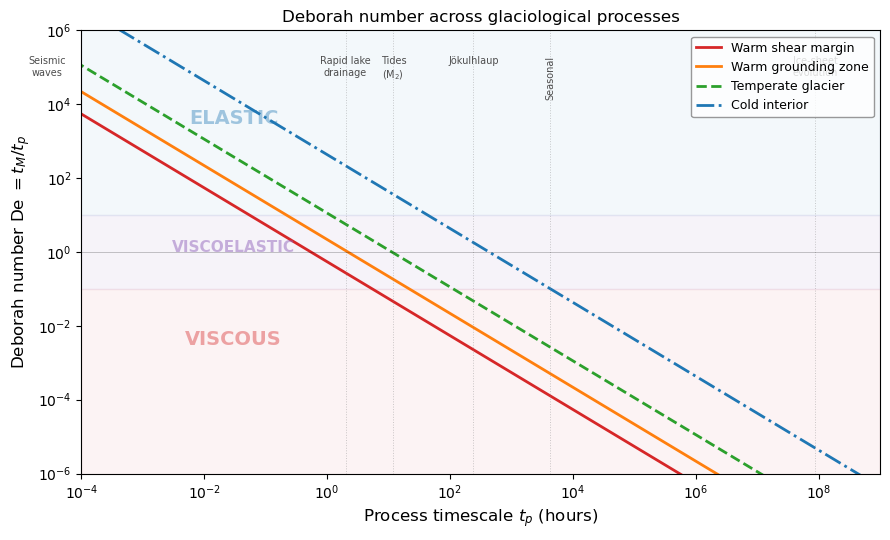

Figure 4 saved.


In [5]:
# ---- Fig 4: Deborah number regime diagram ----
# Process timescales (in seconds)
sec = 1.0
minute = 60
hour = 3600
day = 86400
week = 7 * day
month = 30 * day
year = 365.25 * day

t_p = np.logspace(-2, np.log10(1e5 * year), 500)  # s

# Glaciological settings (T in K, tau_e in Pa)
settings = [
    (270, 0.2e6, 'Warm shear margin', '#d62728', '-'),
    (270, 0.1e6, 'Warm grounding zone', '#ff7f0e', '-'),
    (263, 0.1e6, 'Temperate glacier', '#2ca02c', '--'),
    (243, 0.05e6, 'Cold interior', '#1f77b4', '-.'),
]

fig, ax = plt.subplots(figsize=(9, 5.5))

# Shade regimes
ax.axhspan(0.1, 10, alpha=0.08, color='#9467bd')
ax.axhspan(10, 1e10, alpha=0.05, color='#1f77b4')
ax.axhspan(1e-10, 0.1, alpha=0.05, color='#d62728')

ax.text(3e-2, 3e3, 'ELASTIC', fontsize=14, color='#1f77b4', alpha=0.4,
        ha='center', fontweight='bold')
ax.text(3e-2, 3e-3, 'VISCOUS', fontsize=14, color='#d62728', alpha=0.4,
        ha='center', fontweight='bold')
ax.text(3e-2, 1.0, 'VISCOELASTIC', fontsize=11, color='#9467bd', alpha=0.5,
        ha='center', fontweight='bold')

for T, tau_e, label, col, ls in settings:
    t_M_val = maxwell_time(T, tau_e)
    De = t_M_val / t_p
    ax.loglog(t_p / hour, De, ls, color=col, lw=2, label=label)

# Mark glaciological processes
processes = [
    (0.1 * sec, 'Seismic\nwaves'),
    (12 * hour, 'Tides\n(M$_2$)'),
    (2 * hour, 'Rapid lake\ndrainage'),
    (10 * day, 'Jökulhlaup'),
    (6 * month, 'Seasonal'),
    (1e4 * year, 'Ice-sheet\nevolution'),
]

for t_proc, label in processes:
    ax.axvline(t_proc / hour, color='gray', ls=':', lw=0.7, alpha=0.4)
    ax.text(t_proc / hour, 2e5, label, fontsize=7, ha='center', va='top',
            color='0.3', rotation=90 if len(label) < 10 else 0)

ax.axhline(1.0, color='k', ls='-', lw=0.5, alpha=0.3)

ax.set_xlabel('Process timescale $t_p$ (hours)', fontsize=12)
ax.set_ylabel('Deborah number De $= t_M / t_p$', fontsize=12)
ax.set_title('Deborah number across glaciological processes', fontsize=12)
ax.set_xlim(1e-4, 1e9)
ax.set_ylim(1e-6, 1e6)
ax.legend(fontsize=9, frameon=True, facecolor='white', edgecolor='gray', loc='upper right')

fig.tight_layout()
fig.savefig('figures/fig04_deborah_number.pdf', bbox_inches='tight')
fig.savefig('figures/fig04_deborah_number.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

---
## Figure 5: Supraglacial Lake Flexural Stress

Show how the basal tensile stress beneath a supraglacial lake varies with lake radius and depth, with the tensile strength of ice marked for reference. This complements the worked example in Section 6.3.

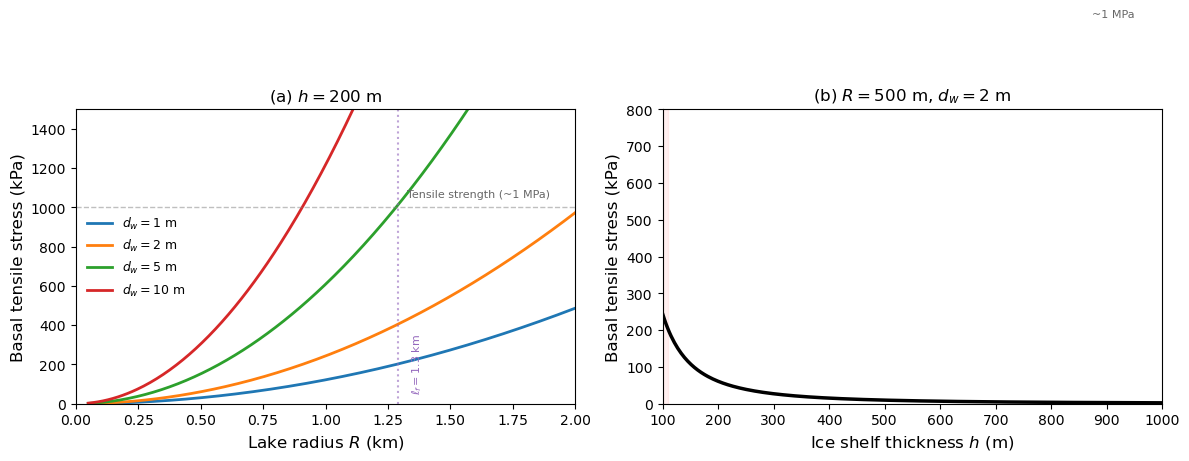

Figure 5 saved.


In [6]:
# ---- Fig 5: Supraglacial lake flexural stress ----
rho_fw = 1000.0  # kg m^{-3}, freshwater

# sigma_tens = 3(1+nu) rho_w g d_w R^2 / (8 h^2)
def lake_stress(d_w, R, h):
    """Basal tensile stress (Pa) beneath circular lake."""
    return 3 * (1 + nu) * rho_fw * g * d_w * R**2 / (8 * h**2)

R_arr = np.linspace(50, 2000, 300)  # m

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Left panel: stress vs lake radius for different depths, h = 200 m ---
h_val = 200  # m
depths = [1, 2, 5, 10]
colors_d = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for d_w, col in zip(depths, colors_d):
    sigma = lake_stress(d_w, R_arr, h_val) / 1e3  # kPa
    ax1.plot(R_arr / 1e3, sigma, '-', color=col, lw=2, label=f'$d_w = {d_w}$ m')

ax1.axhline(1000, color='gray', ls='--', lw=1, alpha=0.5)
ax1.text(1.9, 1050, 'Tensile strength (~1 MPa)', fontsize=8, color='0.4', ha='right')

# Mark the flexural wavelength
lf_200 = flexural_wavelength(h_val)
ax1.axvline(lf_200 / 1e3, color='#9467bd', ls=':', lw=1.5, alpha=0.6)
ax1.text(lf_200 / 1e3 + 0.05, 50, f'$\\ell_f = {lf_200/1e3:.1f}$ km', fontsize=8,
         color='#9467bd', rotation=90, va='bottom')

ax1.set_xlabel('Lake radius $R$ (km)', fontsize=12)
ax1.set_ylabel('Basal tensile stress (kPa)', fontsize=12)
ax1.set_title(f'(a) $h = {h_val}$ m', fontsize=12)
ax1.set_xlim(0, 2)
ax1.set_ylim(0, 1500)
ax1.legend(fontsize=9, frameon=False)

# --- Right panel: stress vs ice thickness for fixed lake, R = 500 m, d_w = 2 m ---
h_arr = np.linspace(100, 1000, 300)
R_fixed = 500  # m
d_fixed = 2    # m

sigma_h = lake_stress(d_fixed, R_fixed, h_arr) / 1e3  # kPa

ax2.plot(h_arr, sigma_h, 'k-', lw=2.5)
ax2.axhline(1000, color='gray', ls='--', lw=1, alpha=0.5)
ax2.text(950, 1050, '~1 MPa', fontsize=8, color='0.4', ha='right')

# Shade the thin-shelf regime where stresses are dangerous
dangerous = sigma_h > 200  # > 200 kPa
if np.any(dangerous):
    h_danger = h_arr[dangerous]
    ax2.axvspan(h_danger[0], h_danger[-1], alpha=0.06, color='red')

ax2.set_xlabel('Ice shelf thickness $h$ (m)', fontsize=12)
ax2.set_ylabel('Basal tensile stress (kPa)', fontsize=12)
ax2.set_title(f'(b) $R = {R_fixed}$ m, $d_w = {d_fixed}$ m', fontsize=12)
ax2.set_xlim(100, 1000)
ax2.set_ylim(0, 800)

fig.tight_layout()
fig.savefig('figures/fig05_lake_stress.pdf', bbox_inches='tight')
fig.savefig('figures/fig05_lake_stress.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

---
## Figure 6: Elastic Moduli Cartoons

Schematic illustrations of the four primary elastic moduli: shear modulus $\mu$, Young's modulus $E$, Poisson's ratio $\nu$, and bulk modulus $K$. Solid rectangles show the undeformed reference state; dashed outlines show the deformed state.

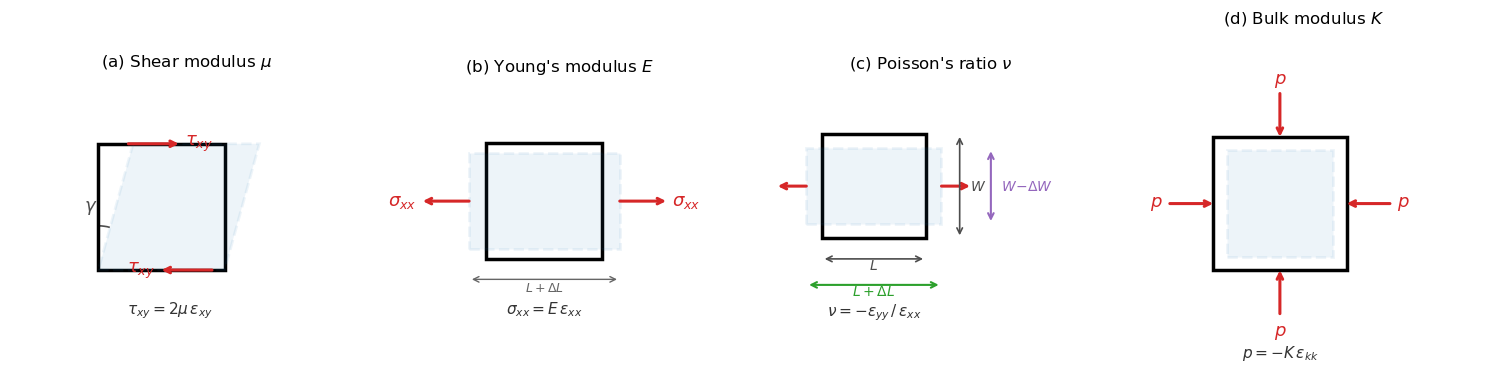

Figure 6 saved.


In [7]:
# ---- Fig 6: Elastic moduli cartoons ----
from matplotlib.patches import Arc

fig, axes = plt.subplots(1, 4, figsize=(15, 5.5))

L = 2.0
lw_ref = 2.5
lw_def = 2.0
col_ref = 'k'
col_def = '#1f77b4'
col_arrow = '#d62728'

def draw_poly(ax, corners, color='k', ls='-', lw=2, fill=False, fc='blue', alpha=0.08):
    poly = plt.Polygon(corners, closed=True, fill=fill,
                        edgecolor=color, ls=ls, lw=lw,
                        facecolor=fc if fill else 'none',
                        alpha=alpha if fill else 1.0, zorder=2)
    ax.add_patch(poly)

def stress_arrow(ax, x, y, dx, dy):
    ax.annotate('', xy=(x+dx, y+dy), xytext=(x, y),
                arrowprops=dict(arrowstyle='->', color=col_arrow, lw=2.2,
                                shrinkA=0, shrinkB=0))

ref = [(0,0), (L,0), (L,L), (0,L)]

# =====================================================================
# (a) Shear modulus — simple shear
# =====================================================================
ax = axes[0]
draw_poly(ax, ref, color=col_ref, lw=lw_ref)

gamma = 0.55
deformed = [(0,0), (L,0), (L+gamma,L), (gamma,L)]
draw_poly(ax, deformed, color=col_def, ls='--', lw=lw_def, fill=True, fc=col_def)

a = 0.8
stress_arrow(ax, gamma/2 + 0.2, L, a, 0)
ax.text(gamma/2 + 0.2 + a + 0.1, L, '$\\tau_{xy}$', fontsize=13, color=col_arrow, va='center')
stress_arrow(ax, L - 0.2, 0, -a, 0)
ax.text(L - 0.2 - a - 0.1, 0, '$\\tau_{xy}$', fontsize=13, color=col_arrow, va='center', ha='right')

arc = Arc((0, 0), 1.4, 1.4, angle=0, theta1=75, theta2=90, color='0.3', lw=1.2)
ax.add_patch(arc)
ax.text(-0.22, 0.95, '$\\gamma$', fontsize=13, color='0.3')

ax.set_title('(a) Shear modulus $\\mu$', fontsize=12, pad=10)
ax.text(L/2 + gamma/4, -0.7, '$\\tau_{xy} = 2\\mu\\,\\varepsilon_{xy}$',
        fontsize=11, ha='center', color='0.2')
ax.set_xlim(-1.4, 4.2); ax.set_ylim(-1.0, 3.0)
ax.set_aspect('equal'); ax.axis('off')

# =====================================================================
# (b) Young's modulus — uniaxial extension
# =====================================================================
ax = axes[1]
draw_poly(ax, ref, color=col_ref, lw=lw_ref)

dx_ext = 0.6
dy_con = 0.35
deformed_E = [(-dx_ext/2, dy_con/2), (L+dx_ext/2, dy_con/2),
              (L+dx_ext/2, L-dy_con/2), (-dx_ext/2, L-dy_con/2)]
draw_poly(ax, deformed_E, color=col_def, ls='--', lw=lw_def, fill=True, fc=col_def)

stress_arrow(ax, L + dx_ext/2, L/2, a, 0)
ax.text(L + dx_ext/2 + a + 0.1, L/2, '$\\sigma_{xx}$', fontsize=13, color=col_arrow, va='center')
stress_arrow(ax, -dx_ext/2, L/2, -a, 0)
ax.text(-dx_ext/2 - a - 0.1, L/2, '$\\sigma_{xx}$', fontsize=13, color=col_arrow, va='center', ha='right')

ax.annotate('', xy=(L+dx_ext/2, -0.35), xytext=(-dx_ext/2, -0.35),
            arrowprops=dict(arrowstyle='<->', color='0.4', lw=1))
ax.text(L/2, -0.55, '$L + \\Delta L$', fontsize=9, ha='center', color='0.4')

ax.set_title("(b) Young's modulus $E$", fontsize=12, pad=10)
ax.text(L/2, -0.95, '$\\sigma_{xx} = E\\,\\varepsilon_{xx}$',
        fontsize=11, ha='center', color='0.2')
ax.set_xlim(-1.8, 4.3); ax.set_ylim(-1.2, 3.0)
ax.set_aspect('equal'); ax.axis('off')

# =====================================================================
# (c) Poisson's ratio — show full deformed vs undeformed dimensions
# =====================================================================
ax = axes[2]
draw_poly(ax, ref, color=col_ref, lw=lw_ref)

dx_c = 0.6
dy_c = 0.55
deformed_C = [(-dx_c/2, dy_c/2), (L+dx_c/2, dy_c/2),
              (L+dx_c/2, L-dy_c/2), (-dx_c/2, L-dy_c/2)]
draw_poly(ax, deformed_C, color=col_def, ls='--', lw=lw_def, fill=True, fc=col_def)

# Light stress arrows
stress_arrow(ax, L + dx_c/2, L/2, 0.55, 0)
stress_arrow(ax, -dx_c/2, L/2, -0.55, 0)

# Full-width dimension lines (easier to read than tiny delta arrows)
# Undeformed width (black) — below the shapes
y_dim = -0.4
ax.annotate('', xy=(L, y_dim), xytext=(0, y_dim),
            arrowprops=dict(arrowstyle='<->', color='0.3', lw=1.2))
ax.text(L/2, y_dim - 0.2, '$L$', fontsize=10, ha='center', color='0.3')

# Deformed width (green) — further below
y_dim2 = -0.9
ax.annotate('', xy=(L+dx_c/2, y_dim2), xytext=(-dx_c/2, y_dim2),
            arrowprops=dict(arrowstyle='<->', color='#2ca02c', lw=1.5))
ax.text(L/2, y_dim2 - 0.2, '$L + \\Delta L$', fontsize=10, ha='center',
        color='#2ca02c', fontweight='bold')

# Undeformed height (black) — to the right
x_dim = L + dx_c/2 + 0.35
ax.annotate('', xy=(x_dim, L), xytext=(x_dim, 0),
            arrowprops=dict(arrowstyle='<->', color='0.3', lw=1.2))
ax.text(x_dim + 0.2, L/2, '$W$', fontsize=10, va='center', color='0.3')

# Deformed height (purple) — further right
x_dim2 = x_dim + 0.6
ax.annotate('', xy=(x_dim2, L-dy_c/2), xytext=(x_dim2, dy_c/2),
            arrowprops=dict(arrowstyle='<->', color='#9467bd', lw=1.5))
ax.text(x_dim2 + 0.2, L/2, '$W\\! -\\! \\Delta W$', fontsize=10, va='center',
        color='#9467bd', fontweight='bold')

ax.set_title("(c) Poisson's ratio $\\nu$", fontsize=12, pad=10)
ax.text(L/2, -1.5, '$\\nu = -\\varepsilon_{yy}\\,/\\,\\varepsilon_{xx}$',
        fontsize=11, ha='center', color='0.2')
ax.set_xlim(-1.3, 5.5); ax.set_ylim(-1.8, 3.0)
ax.set_aspect('equal'); ax.axis('off')

# =====================================================================
# (d) Bulk modulus — uniform compression
# =====================================================================
ax = axes[3]
draw_poly(ax, ref, color=col_ref, lw=lw_ref)

shrink = 0.4
deformed_bulk = [(shrink/2, shrink/2), (L-shrink/2, shrink/2),
                 (L-shrink/2, L-shrink/2), (shrink/2, L-shrink/2)]
draw_poly(ax, deformed_bulk, color=col_def, ls='--', lw=lw_def, fill=True, fc=col_def)

a_p = 0.65
mid = L/2
stress_arrow(ax, L + a_p, mid, -a_p, 0)
ax.text(L + a_p + 0.1, mid, '$p$', fontsize=13, color=col_arrow, va='center')
stress_arrow(ax, -a_p, mid, a_p, 0)
ax.text(-a_p - 0.1, mid, '$p$', fontsize=13, color=col_arrow, va='center', ha='right')
stress_arrow(ax, mid, L + a_p, 0, -a_p)
ax.text(mid, L + a_p + 0.15, '$p$', fontsize=13, color=col_arrow, ha='center')
stress_arrow(ax, mid, -a_p, 0, a_p)
ax.text(mid, -a_p - 0.15, '$p$', fontsize=13, color=col_arrow, ha='center', va='top')

ax.set_title('(d) Bulk modulus $K$', fontsize=12, pad=10)
ax.text(L/2, -1.3, '$p = -K\\,\\varepsilon_{kk}$',
        fontsize=11, ha='center', color='0.2')
ax.set_xlim(-1.3, 4.0); ax.set_ylim(-1.6, 3.5)
ax.set_aspect('equal'); ax.axis('off')

fig.tight_layout()
fig.savefig('figures/fig06_elastic_moduli_cartoons.pdf', bbox_inches='tight')
fig.savefig('figures/fig06_elastic_moduli_cartoons.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure 6 saved.')